# LightURLNet — AShieldER URL Phishing Detector
## Section 1: Environment Setup

In [1]:
# ── Install required packages ────────────────────────────────────────────────
import subprocess, sys

def pip_install(pkgs: list[str]) -> None:
    """Install packages quietly and report outcome."""
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + pkgs
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"[WARN] pip install issues: {result.stderr[:300]}")

pip_install([
    "torch", "torchvision", "torchaudio",
    "pandas", "numpy", "matplotlib",
    "scikit-learn", "tqdm",
    "torchmetrics",
    "onnx", "onnxruntime",
    "requests",
])

print("✓ Package installation complete.")

✓ Package installation complete.


In [2]:
# ── Imports & version verification ───────────────────────────────────────────
import os, sys, random, logging, json, time, warnings, hashlib
from pathlib import Path
from datetime import datetime
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchmetrics
import onnx, onnxruntime as ort
import requests

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print(f"Python        : {sys.version.split()[0]}")
print(f"PyTorch       : {torch.__version__}")
print(f"TorchMetrics  : {torchmetrics.__version__}")
print(f"ONNX          : {onnx.__version__}")
print(f"OnnxRuntime   : {ort.__version__}")
print(f"NumPy         : {np.__version__}")
print(f"Pandas        : {pd.__version__}")
print(f"Matplotlib    : {matplotlib.__version__}")

Python        : 3.12.13
PyTorch       : 2.10.0+cu128
TorchMetrics  : 1.9.0
ONNX          : 1.21.0
OnnxRuntime   : 1.27.0
NumPy         : 2.4.6
Pandas        : 2.3.3
Matplotlib    : 3.10.0


In [3]:
# ── Device detection & random seed ───────────────────────────────────────────
SEED: int = 42

def set_seed(seed: int) -> None:
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

def get_device() -> torch.device:
    """Detect best available compute device."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE: torch.device = get_device()
print(f"Device        : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("LightURLNet")

# ── Global paths ─────────────────────────────────────────────────────────────
ARTIFACT_DIR   = Path("lighturlnet_artifacts");  ARTIFACT_DIR.mkdir(exist_ok=True)
DATASET_PATH   = Path("lighturlnet_dataset.csv")
VOCAB_PATH     = ARTIFACT_DIR / "vocab.json"
CKPT_PATH      = ARTIFACT_DIR / "lighturlnet_best.pt"
ONNX_PATH      = ARTIFACT_DIR / "lighturlnet.onnx"
TS_PATH        = ARTIFACT_DIR / "lighturlnet.ts"
PT_PATH        = ARTIFACT_DIR / "lighturlnet.pt"
REPORT_PATH    = Path("lighturlnet_report.md")
PLOT_DIR       = ARTIFACT_DIR / "plots";  PLOT_DIR.mkdir(exist_ok=True)

# ── Hyper-parameters ─────────────────────────────────────────────────────────
MAX_LEN          : int   = 256
EMBED_DIM        : int   = 64
BATCH_SIZE       : int   = 512
NUM_EPOCHS       : int   = 30
LR               : float = 3e-4
WEIGHT_DECAY     : float = 1e-4
GRAD_CLIP        : float = 1.0
PATIENCE         : int   = 5
DROPOUT          : float = 0.3
CNN_FILTERS      : int   = 128
TRAIN_RATIO      : float = 0.80
VAL_RATIO        : float = 0.10
TEST_RATIO       : float = 0.10

print("\n✓ Environment configured.")
print(f"  Device: {DEVICE} | Seed: {SEED} | MaxLen: {MAX_LEN} | Batch: {BATCH_SIZE}")

Device        : cuda
GPU           : Tesla T4
VRAM          : 15.6 GB

✓ Environment configured.
  Device: cuda | Seed: 42 | MaxLen: 256 | Batch: 512


## Section 2: Dataset Collection

In [4]:
# ── URL validation helpers ────────────────────────────────────────────────────
import re
from urllib.parse import urlparse

_URL_RE = re.compile(
    r'^(?:http[s]?://)?'           # optional scheme
    r'(?:[A-Za-z0-9\-]+\.)+[A-Za-z]{2,}'   # domain
    r'(?:[/?#].*)?$',              # path / query / fragment
    re.IGNORECASE,
)

def is_valid_url(url: str) -> bool:
    """Return True if *url* looks like a real URL (lightweight check)."""
    if not isinstance(url, str) or len(url.strip()) < 4:
        return False
    url = url.strip()
    if len(url) > 2048:
        return False
    try:
        parsed = urlparse(url if "://" in url else "http://" + url)
        if not parsed.netloc or "." not in parsed.netloc:
            return False
    except Exception:
        return False
    return bool(_URL_RE.match(url))


def normalize_url(url: str) -> str:
    """Lowercase and strip whitespace from a URL."""
    return url.strip().lower()

In [5]:
# ── Dataset downloader helpers ────────────────────────────────────────────────

def download_text(url: str, timeout: int = 30, max_bytes: int = 50_000_000) -> Optional[str]:
    """Download text from *url* with graceful failure."""
    try:
        with requests.get(url, timeout=timeout, stream=True) as r:
            r.raise_for_status()
            chunks = []
            total  = 0
            for chunk in r.iter_content(chunk_size=65536, decode_unicode=True):
                if isinstance(chunk, bytes):
                    chunk = chunk.decode("utf-8", errors="replace")
                chunks.append(chunk)
                total += len(chunk)
                if total >= max_bytes:
                    break
            return "".join(chunks)
    except Exception as exc:
        logger.warning(f"Download failed [{url[:60]}...]: {exc}")
        return None


def safe_download_lines(url: str) -> list[str]:
    """Return non-empty lines from a downloaded text file."""
    content = download_text(url)
    if content is None:
        return []
    return [ln.strip() for ln in content.splitlines() if ln.strip()]

In [6]:
# ── Per-source download functions ────────────────────────────────────────────

def fetch_phishtank(n: int = 50000) -> pd.DataFrame:
    """Fetch phishing URLs from PhishTank CSV (no API key needed for the free list)."""
    # PhishTank online valid phish list (updated every 5 min):
    urls_to_try = [
        "https://data.phishtank.com/data/online-valid.csv",
        "http://data.phishtank.com/data/online-valid.csv",
    ]
    for src in urls_to_try:
        text = download_text(src, timeout=60, max_bytes=80_000_000)
        if text:
            try:
                from io import StringIO
                df = pd.read_csv(StringIO(text), usecols=lambda c: c in
                                 {"url", "phish_detail_url", "submission_time", "target"})
                if "url" in df.columns:
                    phishing = df["url"].dropna().astype(str).tolist()
                    phishing = [u for u in phishing if is_valid_url(u)][:n]
                    logger.info(f"PhishTank: {len(phishing):,} phishing URLs")
                    return pd.DataFrame({"url": phishing, "label": 1})
            except Exception as exc:
                logger.warning(f"PhishTank parse error: {exc}")
    return pd.DataFrame(columns=["url", "label"])


def fetch_openphish(n: int = 30000) -> pd.DataFrame:
    """Fetch phishing URLs from OpenPhish community feed."""
    lines = safe_download_lines("https://openphish.com/feed.txt")
    phishing = [l for l in lines if is_valid_url(l)][:n]
    logger.info(f"OpenPhish: {len(phishing):,} phishing URLs")
    return pd.DataFrame({"url": phishing, "label": 1})


def fetch_urlhaus(n: int = 30000) -> pd.DataFrame:
    """Fetch malicious URLs from URLhaus (label as phishing/malicious=1)."""
    text = download_text(
        "https://urlhaus.abuse.ch/downloads/csv_online/",
        timeout=60, max_bytes=80_000_000,
    )
    if text is None:
        return pd.DataFrame(columns=["url", "label"])
    lines = [l for l in text.splitlines() if l and not l.startswith("#")]
    urls = []
    for line in lines:
        parts = line.split(",")
        if len(parts) >= 3:
            candidate = parts[2].strip().strip('"')
            if is_valid_url(candidate):
                urls.append(candidate)
        if len(urls) >= n:
            break
    logger.info(f"URLHaus: {len(urls):,} malicious URLs")
    return pd.DataFrame({"url": urls, "label": 1})


def fetch_phishing_database(n: int = 30000) -> pd.DataFrame:
    """Fetch from mitchellkrogza/Phishing.Database on GitHub."""
    base = "https://raw.githubusercontent.com/mitchellkrogza/Phishing.Database/master/phishing-links-ACTIVE-TODAY.lst"
    lines = safe_download_lines(base)
    phishing = [l for l in lines if is_valid_url(l)][:n]
    logger.info(f"Phishing.Database: {len(phishing):,} phishing URLs")
    return pd.DataFrame({"url": phishing, "label": 1})


def fetch_tranco(n: int = 100000) -> pd.DataFrame:
    """Fetch benign URLs from Tranco top-1M list."""
    text = download_text(
        "https://tranco-list.eu/top-1m.csv.zip",
        timeout=90, max_bytes=80_000_000,
    )
    # Fallback to plain text version
    if text is None or len(text) < 100:
        lines = safe_download_lines("https://tranco-list.eu/download/Z3WGN/full")
        if not lines:
            # Second fallback — Majestic Million
            lines = safe_download_lines(
                "https://downloads.majestic.com/majestic_million.csv"
            )
    else:
        lines = text.splitlines()

    benign_urls = []
    for line in lines:
        # Tranco format: rank,domain  or  rank,domain,extra
        parts = line.strip().split(",")
        domain = parts[1].strip() if len(parts) >= 2 else parts[0].strip()
        domain = domain.strip('"').strip()
        if domain and "." in domain and len(domain) > 3:
            benign_urls.append("https://" + domain)
        if len(benign_urls) >= n:
            break
    logger.info(f"Tranco benign: {len(benign_urls):,} URLs")
    return pd.DataFrame({"url": benign_urls, "label": 0})


def fetch_majestic(n: int = 50000) -> pd.DataFrame:
    """Fetch benign URLs from Majestic Million."""
    text = download_text(
        "https://downloads.majestic.com/majestic_million.csv",
        timeout=60, max_bytes=50_000_000,
    )
    if text is None:
        return pd.DataFrame(columns=["url", "label"])
    lines = text.splitlines()[1:]   # skip header
    benign_urls = []
    for line in lines:
        parts = line.split(",")
        if len(parts) >= 3:
            domain = parts[2].strip().strip('"')
        elif len(parts) >= 2:
            domain = parts[1].strip().strip('"')
        else:
            continue
        if domain and "." in domain:
            benign_urls.append("https://" + domain)
        if len(benign_urls) >= n:
            break
    logger.info(f"Majestic benign: {len(benign_urls):,} URLs")
    return pd.DataFrame({"url": benign_urls, "label": 0})

In [7]:
# ── Synthetic URL generators (offline fallback) ───────────────────────────────

_BENIGN_TLDS  = [".com", ".org", ".net", ".edu", ".gov", ".io", ".co", ".info"]
_PHISH_PATS   = [
    "secure-{brand}-login-verify.com/account",
    "signin-{brand}-verification.net/update",
    "{brand}-account-suspended.xyz/restore",
    "paypal-billing.{rnd}.com/confirm",
    "appleid-{rnd}.gq/itunes/signin",
    "secure.{brand}-password-reset.com/validate",
    "updatebilling-{brand}.com/payment",
    "{brand}-security-alert.ga/login",
    "login-{brand}-support.ml/help",
    "verify.{rnd}-{brand}-id.tk/auth",
]
_BRANDS = ["paypal", "amazon", "apple", "google", "microsoft", "netflix",
           "facebook", "instagram", "twitter", "ebay", "bankofamerica",
           "wellsfargo", "chase", "citibank", "dhl", "fedex", "irs"]
_WORDS  = ["shop", "news", "blog", "store", "home", "health", "tech",
           "media", "web", "data", "cloud", "digital", "auto", "smart"]

def _rnd_str(n: int = 6) -> str:
    return "".join(random.choices("abcdefghijklmnopqrstuvwxyz0123456789", k=n))

def generate_synthetic_benign(n: int) -> pd.DataFrame:
    """Generate plausible benign URLs for offline fallback."""
    urls = []
    for _ in range(n):
        word1 = random.choice(_WORDS)
        word2 = random.choice(_WORDS)
        tld   = random.choice(_BENIGN_TLDS)
        path  = random.choice(["", "/about", "/contact", "/products",
                                "/blog/" + _rnd_str(4), "/news/" + _rnd_str(4)])
        urls.append(f"https://{word1}{word2}{tld}{path}")
    return pd.DataFrame({"url": urls, "label": 0})

def generate_synthetic_phishing(n: int) -> pd.DataFrame:
    """Generate realistic phishing-looking URLs for offline fallback."""
    urls = []
    for _ in range(n):
        pat   = random.choice(_PHISH_PATS)
        brand = random.choice(_BRANDS)
        rnd   = _rnd_str(random.randint(4, 10))
        url   = pat.format(brand=brand, rnd=rnd)
        prefix = random.choice(["http://", "https://"])
        urls.append(prefix + url)
    return pd.DataFrame({"url": urls, "label": 1})

In [8]:
# ── Main dataset builder ───────────────────────────────────────────────────────

def build_dataset(
    target_benign : int = 90_000,
    target_phishing: int = 90_000,
    local_csv     : Optional[Path] = None,
) -> pd.DataFrame:
    """
    Attempt online collection → synthesize any shortfall → clean → deduplicate.
    Returns a balanced DataFrame with columns [url, label].
    """
    phishing_frames: list[pd.DataFrame] = []
    benign_frames  : list[pd.DataFrame] = []

    # ── 1. Try online sources ─────────────────────────────────────────────────
    logger.info("Fetching phishing URLs …")
    phishing_frames.append(fetch_phishtank(50_000))
    phishing_frames.append(fetch_openphish(30_000))
    phishing_frames.append(fetch_urlhaus(30_000))
    phishing_frames.append(fetch_phishing_database(30_000))

    logger.info("Fetching benign URLs …")
    benign_frames.append(fetch_tranco(100_000))
    benign_frames.append(fetch_majestic(50_000))

    phishing_df = pd.concat(phishing_frames, ignore_index=True)
    benign_df   = pd.concat(benign_frames,   ignore_index=True)

    logger.info(f"Online phishing: {len(phishing_df):,}  | benign: {len(benign_df):,}")

    # ── 2. Normalize ──────────────────────────────────────────────────────────
    for df in (phishing_df, benign_df):
        df["url"] = df["url"].astype(str).str.strip().str.lower()

    # ── 3. Validate ───────────────────────────────────────────────────────────
    phishing_df = phishing_df[phishing_df["url"].apply(is_valid_url)].copy()
    benign_df   = benign_df[benign_df["url"].apply(is_valid_url)].copy()

    # ── 4. Deduplicate across splits ─────────────────────────────────────────
    combined = pd.concat([phishing_df, benign_df], ignore_index=True)
    before_dedup = len(combined)
    combined.drop_duplicates(subset="url", keep="first", inplace=True)
    after_dedup = len(combined)
    duplicates_removed = before_dedup - after_dedup

    phishing_df = combined[combined["label"] == 1].copy()
    benign_df   = combined[combined["label"] == 0].copy()

    # ── 5. Synthesize shortfall ───────────────────────────────────────────────
    if len(phishing_df) < target_phishing:
        need = target_phishing - len(phishing_df)
        logger.info(f"Synthesizing {need:,} phishing URLs …")
        phishing_df = pd.concat(
            [phishing_df, generate_synthetic_phishing(need)], ignore_index=True
        )

    if len(benign_df) < target_benign:
        need = target_benign - len(benign_df)
        logger.info(f"Synthesizing {need:,} benign URLs …")
        benign_df = pd.concat(
            [benign_df, generate_synthetic_benign(need)], ignore_index=True
        )

    # ── 6. Balance & sample ───────────────────────────────────────────────────
    phishing_df = phishing_df.sample(n=min(target_phishing, len(phishing_df)),
                                     random_state=SEED).reset_index(drop=True)
    benign_df   = benign_df.sample(n=min(target_benign,   len(benign_df)),
                                   random_state=SEED).reset_index(drop=True)

    final_df = pd.concat([phishing_df, benign_df], ignore_index=True)
    final_df = final_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    final_df["label"] = final_df["label"].astype(int)

    return final_df, duplicates_removed


logger.info("Building dataset … (this may take a few minutes)")
df_raw, n_dupes = build_dataset(target_benign=90_000, target_phishing=90_000)

df_raw.to_csv(DATASET_PATH, index=False)
logger.info(f"Dataset saved → {DATASET_PATH}")

# ── Dataset report ─────────────────────────────────────────────────────────────
n_total    = len(df_raw)
n_benign   = int((df_raw["label"] == 0).sum())
n_phishing = int((df_raw["label"] == 1).sum())
url_lens   = df_raw["url"].str.len()
vocab_chars = set("".join(df_raw["url"].tolist()))
avg_len    = float(url_lens.mean())
max_len    = int(url_lens.max())
min_len_v  = int(url_lens.min())

print("\n" + "="*60)
print("  DATASET REPORT")
print("="*60)
print(f"  Total samples     : {n_total:>10,}")
print(f"  Benign            : {n_benign:>10,}")
print(f"  Phishing          : {n_phishing:>10,}")
print(f"  Duplicates removed: {n_dupes:>10,}")
print(f"  Avg URL length    : {avg_len:>10.1f}")
print(f"  Max URL length    : {max_len:>10}")
print(f"  Min URL length    : {min_len_v:>10}")
print(f"  Vocabulary size   : {len(vocab_chars):>10}")
print("="*60)

07:57:54 [INFO] Building dataset … (this may take a few minutes)
07:57:54 [INFO] Fetching phishing URLs …
07:57:58 [INFO] PhishTank: 50,000 phishing URLs
07:57:59 [INFO] OpenPhish: 294 phishing URLs
07:58:00 [INFO] URLHaus: 9,075 malicious URLs
07:58:00 [WARNING] Download failed [https://raw.githubusercontent.com/mitchellkrogza/Phishing.Da...]: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/mitchellkrogza/Phishing.Database/master/phishing-links-ACTIVE-TODAY.lst
07:58:00 [INFO] Phishing.Database: 0 phishing URLs
07:58:00 [INFO] Fetching benign URLs …
07:58:02 [INFO] Tranco benign: 29,583 URLs
07:58:06 [INFO] Majestic benign: 50,000 URLs
07:58:06 [INFO] Online phishing: 59,369  | benign: 79,583
07:58:07 [INFO] Synthesizing 30,651 phishing URLs …
07:58:07 [INFO] Synthesizing 40,036 benign URLs …
07:58:07 [INFO] Dataset saved → lighturlnet_dataset.csv



  DATASET REPORT
  Total samples     :    180,000
  Benign            :     90,000
  Phishing          :     90,000
  Duplicates removed:         20
  Avg URL length    :       38.2
  Max URL length    :       1261
  Min URL length    :         12
  Vocabulary size   :         78


## Section 3: Exploratory Data Analysis

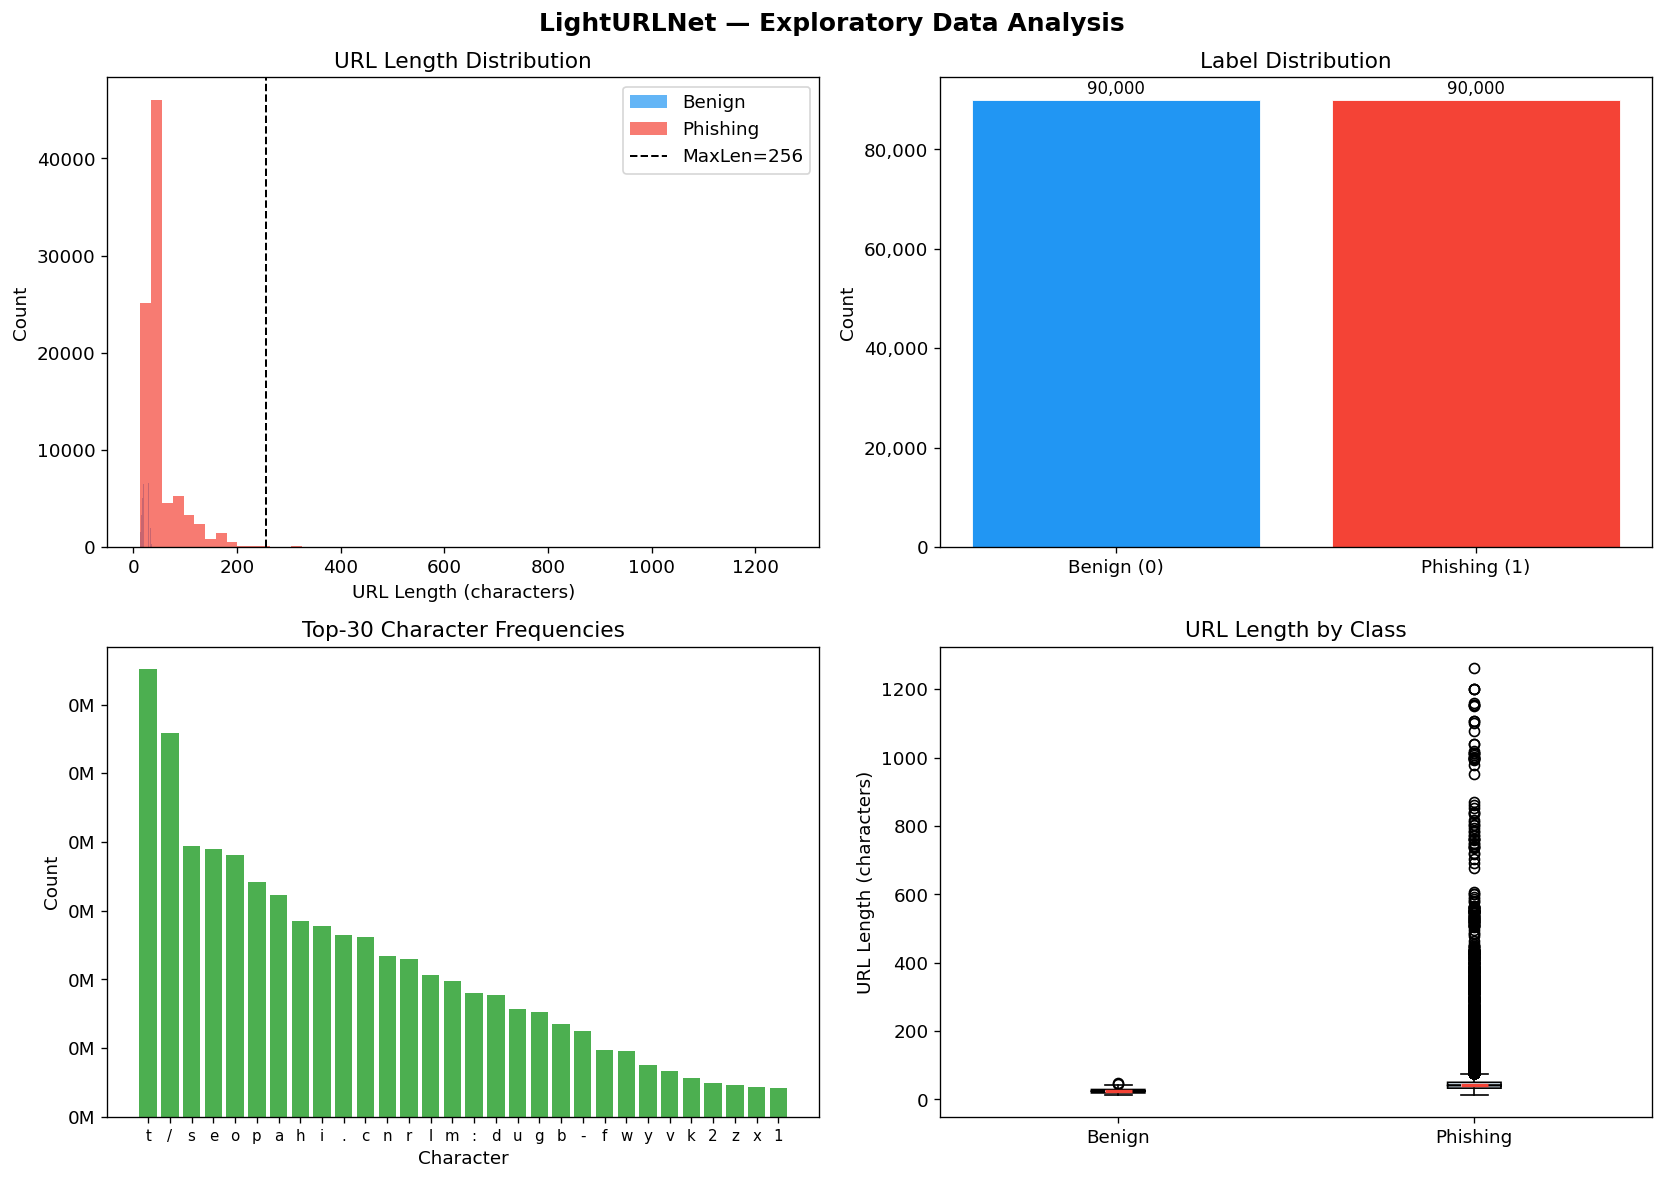

✓ EDA plot saved → lighturlnet_artifacts/plots/eda_overview.png


In [9]:
# ── EDA: URL length histogram ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("LightURLNet — Exploratory Data Analysis", fontsize=15, fontweight="bold")

lengths = df_raw["url"].str.len()
ax = axes[0, 0]
ax.hist(lengths[df_raw["label"] == 0], bins=60, alpha=0.7,
        color="#2196F3", label="Benign", edgecolor="none")
ax.hist(lengths[df_raw["label"] == 1], bins=60, alpha=0.7,
        color="#F44336", label="Phishing", edgecolor="none")
ax.set_title("URL Length Distribution")
ax.set_xlabel("URL Length (characters)")
ax.set_ylabel("Count")
ax.legend()
ax.axvline(MAX_LEN, color="black", linestyle="--", linewidth=1.2, label=f"MaxLen={MAX_LEN}")
ax.legend()

# ── Label distribution ────────────────────────────────────────────────────────
ax2 = axes[0, 1]
counts = df_raw["label"].value_counts().sort_index()
bars = ax2.bar(["Benign (0)", "Phishing (1)"], counts.values,
               color=["#2196F3", "#F44336"], edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
             f"{val:,}", ha="center", va="bottom", fontsize=10)
ax2.set_title("Label Distribution")
ax2.set_ylabel("Count")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Character frequency ───────────────────────────────────────────────────────
from collections import Counter
char_counts = Counter("".join(df_raw["url"].tolist()))
top_chars   = char_counts.most_common(30)
chars, freqs = zip(*top_chars)

ax3 = axes[1, 0]
ax3.bar(range(len(chars)), freqs, color="#4CAF50", edgecolor="none")
ax3.set_xticks(range(len(chars)))
ax3.set_xticklabels(list(chars), fontsize=9)
ax3.set_title("Top-30 Character Frequencies")
ax3.set_xlabel("Character")
ax3.set_ylabel("Count")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1e6):.0f}M"))

# ── Length statistics box ─────────────────────────────────────────────────────
ax4 = axes[1, 1]
bplot = ax4.boxplot(
    [lengths[df_raw["label"] == 0].values, lengths[df_raw["label"] == 1].values],
    labels=["Benign", "Phishing"],
    patch_artist=True,
    notch=True,
    boxprops=dict(facecolor="#E3F2FD"),
    medianprops=dict(color="#F44336", linewidth=2),
)
ax4.set_title("URL Length by Class")
ax4.set_ylabel("URL Length (characters)")

plt.tight_layout()
eda_path = PLOT_DIR / "eda_overview.png"
plt.savefig(eda_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"✓ EDA plot saved → {eda_path}")

## Section 4: Character Vocabulary

In [10]:
# ── Build character vocabulary ────────────────────────────────────────────────

class CharVocabulary:
    """Build and manage a character-level vocabulary with special tokens."""

    PAD_TOKEN: str = "<PAD>"
    UNK_TOKEN: str = "<UNK>"

    def __init__(self, min_freq: int = 2) -> None:
        self.min_freq       = min_freq
        self.char_to_idx    : dict[str, int] = {}
        self.idx_to_char    : dict[int, str] = {}
        self._built         = False

    # ── Build ─────────────────────────────────────────────────────────────────
    def build(self, urls: list[str]) -> None:
        """Scan *urls* and create vocabulary."""
        from collections import Counter
        freq = Counter(c for url in urls for c in url)

        self.char_to_idx = {
            self.PAD_TOKEN: 0,
            self.UNK_TOKEN: 1,
        }
        idx = 2
        for char, count in sorted(freq.items(), key=lambda x: -x[1]):
            if count >= self.min_freq:
                self.char_to_idx[char] = idx
                idx += 1

        self.idx_to_char = {v: k for k, v in self.char_to_idx.items()}
        self._built = True

    # ── Encode ────────────────────────────────────────────────────────────────
    def encode(self, url: str, max_len: int) -> list[int]:
        """Encode *url* to a fixed-length integer list."""
        unk = self.char_to_idx[self.UNK_TOKEN]
        pad = self.char_to_idx[self.PAD_TOKEN]
        encoded = [self.char_to_idx.get(c, unk) for c in url[:max_len]]
        encoded += [pad] * (max_len - len(encoded))
        return encoded

    # ── Properties ───────────────────────────────────────────────────────────
    @property
    def vocab_size(self) -> int:
        return len(self.char_to_idx)

    @property
    def pad_idx(self) -> int:
        return self.char_to_idx[self.PAD_TOKEN]

    # ── Serialise ─────────────────────────────────────────────────────────────
    def save(self, path: Path) -> None:
        with open(path, "w") as fh:
            json.dump({"char_to_idx": self.char_to_idx,
                       "idx_to_char": {str(k): v
                                       for k, v in self.idx_to_char.items()}}, fh)

    @classmethod
    def load(cls, path: Path) -> "CharVocabulary":
        with open(path) as fh:
            data = json.load(fh)
        vocab = cls()
        vocab.char_to_idx = data["char_to_idx"]
        vocab.idx_to_char = {int(k): v for k, v in data["idx_to_char"].items()}
        vocab._built = True
        return vocab


# ── Instantiate & build ────────────────────────────────────────────────────────
vocab = CharVocabulary(min_freq=1)
vocab.build(df_raw["url"].tolist())
vocab.save(VOCAB_PATH)

print(f"Vocabulary size : {vocab.vocab_size:,}")
print(f"PAD index       : {vocab.pad_idx}")
print(f"UNK index       : {vocab.char_to_idx[CharVocabulary.UNK_TOKEN]}")
print(f"Saved            → {VOCAB_PATH}")
print()

top_n = 20
sorted_chars = sorted(
    [(k, v) for k, v in vocab.char_to_idx.items() if k not in ("<PAD>", "<UNK>")],
    key=lambda x: x[1]
)[:top_n]
print(f"First {top_n} vocabulary entries:")
for ch, idx in sorted_chars:
    print(f"  [{idx:>3}] = {repr(ch)}")

Vocabulary size : 80
PAD index       : 0
UNK index       : 1
Saved            → lighturlnet_artifacts/vocab.json

First 20 vocabulary entries:
  [  2] = 't'
  [  3] = '/'
  [  4] = 's'
  [  5] = 'e'
  [  6] = 'o'
  [  7] = 'p'
  [  8] = 'a'
  [  9] = 'h'
  [ 10] = 'i'
  [ 11] = '.'
  [ 12] = 'c'
  [ 13] = 'n'
  [ 14] = 'r'
  [ 15] = 'l'
  [ 16] = 'm'
  [ 17] = ':'
  [ 18] = 'd'
  [ 19] = 'u'
  [ 20] = 'g'
  [ 21] = 'b'


## Section 5: Character Encoding Pipeline

In [11]:
# ── Character-level tokenizer ────────────────────────────────────────────────

class CharTokenizer:
    """Stateless encoder that wraps a CharVocabulary and converts URLs to tensors."""

    def __init__(self, vocabulary: CharVocabulary, max_len: int = 256) -> None:
        self.vocab   = vocabulary
        self.max_len = max_len

    def __call__(self, url: str) -> torch.Tensor:
        """Encode *url* → 1D LongTensor of shape (max_len,)."""
        url = normalize_url(url) if url else ""
        indices = self.vocab.encode(url, self.max_len)
        return torch.tensor(indices, dtype=torch.long)

    def batch_encode(self, urls: list[str]) -> torch.Tensor:
        """Encode a list of URLs → 2D LongTensor of shape (N, max_len)."""
        return torch.stack([self(u) for u in urls])


# ── Verify tokenizer ──────────────────────────────────────────────────────────
tokenizer = CharTokenizer(vocab, max_len=MAX_LEN)

test_urls = [
    "https://secure-paypal-login-verification.com/login",
    "https://google.com",
    "",
    "notaurl",
    "http://x" * 100,    # very long
]

print("Tokenizer smoke-test:")
for u in test_urls:
    t = tokenizer(u)
    assert t.shape == (MAX_LEN,), f"Shape mismatch: {t.shape}"
    print(f"  len={len(u):4d} → tensor shape={tuple(t.shape)}, "
          f"non-pad={int((t != vocab.pad_idx).sum())}")

print("✓ Tokenizer OK") 

Tokenizer smoke-test:
  len=  50 → tensor shape=(256,), non-pad=50
  len=  18 → tensor shape=(256,), non-pad=18
  len=   0 → tensor shape=(256,), non-pad=0
  len=   7 → tensor shape=(256,), non-pad=7
  len= 800 → tensor shape=(256,), non-pad=256
✓ Tokenizer OK


## Section 6: PyTorch Dataset & DataLoaders

In [12]:
# ── LightURLDataset ───────────────────────────────────────────────────────────

class LightURLDataset(Dataset):
    """
    Character-level URL dataset.

    Parameters
    ----------
    urls    : list of raw URL strings
    labels  : list of int labels (0=benign, 1=phishing)
    tokenizer : CharTokenizer instance
    """

    def __init__(
        self,
        urls      : list[str],
        labels    : list[int],
        tokenizer : CharTokenizer,
    ) -> None:
        assert len(urls) == len(labels), "urls/labels length mismatch"
        self.urls      = urls
        self.labels    = labels
        self.tokenizer = tokenizer

    def __len__(self) -> int:
        return len(self.urls)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        try:
            x = self.tokenizer(self.urls[idx])
            y = torch.tensor(self.labels[idx], dtype=torch.float32)
            return x, y
        except Exception:
            # Return a zero-padded tensor on error
            x = torch.zeros(self.tokenizer.max_len, dtype=torch.long)
            y = torch.tensor(0, dtype=torch.float32)
            return x, y

In [13]:
# ── Train / val / test split ──────────────────────────────────────────────────

all_urls   = df_raw["url"].tolist()
all_labels = df_raw["label"].tolist()

# Stratified split: 80 / 10 / 10
X_train, X_temp, y_train, y_temp = train_test_split(
    all_urls, all_labels,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=all_labels,
)

val_size = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=(1 - val_size),
    random_state=SEED,
    stratify=y_temp,
)

print(f"Train : {len(X_train):>7,}  (benign={y_train.count(0):,}, phishing={y_train.count(1):,})")
print(f"Val   : {len(X_val):>7,}  (benign={y_val.count(0):,},   phishing={y_val.count(1):,})")
print(f"Test  : {len(X_test):>7,}  (benign={y_test.count(0):,},   phishing={y_test.count(1):,})")

train_ds = LightURLDataset(X_train, y_train, tokenizer)
val_ds   = LightURLDataset(X_val,   y_val,   tokenizer)
test_ds  = LightURLDataset(X_test,  y_test,  tokenizer)

Train : 144,000  (benign=72,000, phishing=72,000)
Val   :  18,000  (benign=9,000,   phishing=9,000)
Test  :  18,000  (benign=9,000,   phishing=9,000)


In [14]:
# ── Class imbalance detection & sampler ──────────────────────────────────────

n_pos      = sum(y_train)
n_neg      = len(y_train) - n_pos
imbalance_ratio = max(n_pos, n_neg) / (min(n_pos, n_neg) + 1e-9)
USE_SAMPLER: bool = imbalance_ratio > 1.5

print(f"Train positives  : {n_pos:,}")
print(f"Train negatives  : {n_neg:,}")
print(f"Imbalance ratio  : {imbalance_ratio:.2f}")
print(f"WeightedSampler  : {USE_SAMPLER}")

if USE_SAMPLER:
    class_counts  = torch.tensor([n_neg, n_pos], dtype=torch.float)
    class_weights = 1.0 / class_counts
    sample_weights = torch.tensor(
        [class_weights[int(lbl)] for lbl in y_train], dtype=torch.float
    )
    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )
else:
    pos_weight_val = torch.tensor([n_neg / (n_pos + 1e-9)], dtype=torch.float).to(DEVICE)
    train_loader   = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE.type == "cuda"),
)

# Quick loader sanity check
_xb, _yb = next(iter(train_loader))
assert _xb.shape == (BATCH_SIZE, MAX_LEN) or _xb.shape[0] <= BATCH_SIZE
print(f"\n✓ DataLoaders ready | batch shape: {tuple(_xb.shape)}")

Train positives  : 72,000
Train negatives  : 72,000
Imbalance ratio  : 1.00
WeightedSampler  : False

✓ DataLoaders ready | batch shape: (512, 256)


## Section 7: LightURLNet Architecture

In [15]:
# ── Channel Attention module ──────────────────────────────────────────────────

class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation style channel attention for 1-D feature maps."""

    def __init__(self, in_channels: int, reduction: int = 4) -> None:
        super().__init__()
        mid = max(in_channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(
            nn.Linear(in_channels, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, C, L) → (B, C, L) re-weighted."""
        s = self.pool(x).squeeze(-1)      # (B, C)
        w = self.fc(s).unsqueeze(-1)      # (B, C, 1)
        return x * w


# ── Residual Conv Block ───────────────────────────────────────────────────────

class ResConvBlock(nn.Module):
    """
    Single residual CNN branch:
        Conv1d(kernel_size) → BN → ReLU → Conv1d(1) → BN → Residual → ReLU
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int) -> None:
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, 1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)

        self.skip  = (
            nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm1d(out_channels),
            ) if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + residual, inplace=True)

In [16]:
# ── LightURLNet ───────────────────────────────────────────────────────────────

class LightURLNet(nn.Module):
    """
    Lightweight character-level CNN for phishing URL detection.

    Architecture
    ------------
    Embedding(vocab_size, embed_dim)
    ├── ResConvBlock(k=3)
    ├── ResConvBloc(k=5)
    └── ResConvBlock(k=7)k
    ChannelAttention → Fusion Conv → GlobalMaxPool → Dense → Dropout → Sigmoid 
    """

    def __init__(
        self,
        vocab_size  : int,
        embed_dim   : int  = 64,
        num_filters : int  = 128,
        dropout     : float = 0.3,
    ) -> None:
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0,
        )

        # Multi-scale CNN branches
        self.branch3 = ResConvBlock(embed_dim, num_filters, kernel_size=3)
        self.branch5 = ResConvBlock(embed_dim, num_filters, kernel_size=5)
        self.branch7 = ResConvBlock(embed_dim, num_filters, kernel_size=7)

        fused_channels = num_filters * 3   # concat 3 branches

        # Residual fusion → channel attention
        self.fusion_conv = nn.Sequential(
            nn.Conv1d(fused_channels, num_filters, kernel_size=1, bias=False),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(inplace=True),
        )
        self.channel_attn = ChannelAttention(num_filters, reduction=4)
        self.pool         = nn.AdaptiveMaxPool1d(1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(num_filters, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(64, 1),
        )

        # Weight initialisation
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                with torch.no_grad():
                    m.weight[m.padding_idx].fill_(0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : LongTensor (B, L)  — character indices

        Returns
        -------
        Tensor (B,) — raw logit (before sigmoid)
        """
        emb = self.embedding(x)           # (B, L, E)
        emb = emb.transpose(1, 2)         # (B, E, L)

        b3 = self.branch3(emb)            # (B, F, L)
        b5 = self.branch5(emb)            # (B, F, L)
        b7 = self.branch7(emb)            # (B, F, L)

        fused = torch.cat([b3, b5, b7], dim=1)   # (B, 3F, L)
        fused = self.fusion_conv(fused)           # (B, F, L)
        fused = self.channel_attn(fused)          # (B, F, L)

        pooled = self.pool(fused).squeeze(-1)     # (B, F)
        logit  = self.classifier(pooled)          # (B, 1)
        return logit.squeeze(-1)                  # (B,)

In [17]:
# ── Model instantiation & summary ─────────────────────────────────────────────

model = LightURLNet(
    vocab_size  = vocab.vocab_size,
    embed_dim   = EMBED_DIM,
    num_filters = CNN_FILTERS,
    dropout     = DROPOUT,
).to(DEVICE)

# ── Parameter count ────────────────────────────────────────────────────────────
total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb  = total_params * 4 / 1e6   # float32

print("=" * 50)
print("  LightURLNet — Model Summary")
print("=" * 50)
print(f"  Vocab size          : {vocab.vocab_size:,}")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable params    : {trainable_params:,}")
print(f"  Model size (FP32)   : {model_size_mb:.2f} MB")
print(f"  Param budget (<500K): {'✓ PASS' if total_params < 500_000 else '✗ OVER BUDGET'}")
print("=" * 50)

# Forward-pass smoke test
with torch.no_grad():
    _dummy = torch.zeros(4, MAX_LEN, dtype=torch.long).to(DEVICE)
    _out   = model(_dummy)
    assert _out.shape == (4,), f"Output shape error: {_out.shape}"
print("✓ Forward pass OK")

  LightURLNet — Model Summary
  Vocab size          : 80
  Total parameters    : 270,113
  Trainable params    : 270,113
  Model size (FP32)   : 1.08 MB
  Param budget (<500K): ✓ PASS
✓ Forward pass OK


## Section 8: Training Pipeline

In [18]:
# ── Loss & optimiser setup ────────────────────────────────────────────────────

# Compute positive class weight for BCEWithLogitsLoss
n_pos_train = sum(y_train)
n_neg_train = len(y_train) - n_pos_train
pos_weight  = torch.tensor([n_neg_train / (n_pos_train + 1e-9)],
                           dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=LR * 1e-2,
)

# Mixed-precision scaler (CUDA only)
scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

print(f"Loss       : BCEWithLogitsLoss (pos_weight={pos_weight.item():.3f})")
print(f"Optimiser  : AdamW (lr={LR}, wd={WEIGHT_DECAY})")
print(f"Scheduler  : CosineAnnealingLR (T_max={NUM_EPOCHS})")
print(f"AMP        : {DEVICE.type == 'cuda'}")

Loss       : BCEWithLogitsLoss (pos_weight=1.000)
Optimiser  : AdamW (lr=0.0003, wd=0.0001)
Scheduler  : CosineAnnealingLR (T_max=30)
AMP        : True


In [19]:
# ── Training & evaluation helpers ─────────────────────────────────────────────

def run_epoch(
    model     : nn.Module,
    loader    : DataLoader,
    criterion : nn.Module,
    optimizer : Optional[torch.optim.Optimizer] = None,
    scaler    : Optional[GradScaler]            = None,
) -> dict:
    """Run a single training or evaluation epoch."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels, all_probs = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            with autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(xb)
                loss   = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    optimizer.step()

            total_loss += loss.item() * xb.size(0)
            probs = torch.sigmoid(logits).detach().cpu()
            all_probs.extend(probs.tolist())
            all_labels.extend(yb.detach().cpu().tolist())

    n       = len(all_labels)
    preds   = [1 if p >= 0.5 else 0 for p in all_probs]
    metrics = {
        "loss"     : total_loss / n,
        "accuracy" : accuracy_score(all_labels, preds),
        "f1"       : f1_score(all_labels, preds, zero_division=0),
        "recall"   : recall_score(all_labels, preds, zero_division=0),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "roc_auc"  : roc_auc_score(all_labels, all_probs),
    }
    return metrics

In [20]:
# ── Training loop ─────────────────────────────────────────────────────────────

history: dict[str, list] = {
    "train_loss": [], "val_loss": [],
    "train_f1"  : [], "val_f1"  : [],
    "train_auc" : [], "val_auc" : [],
    "lr"        : [],
}

best_val_f1   = 0.0
patience_ctr  = 0
best_epoch    = 0

print(f"{'Epoch':>5} | {'TrLoss':>8} | {'TrF1':>6} | {'VaLoss':>8} | {'VaF1':>6} | {'LR':>9} | {'EStop'}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0     = time.time()
    tr_m   = run_epoch(model, train_loader, criterion, optimizer, scaler)
    va_m   = run_epoch(model, val_loader,   criterion)
    scheduler.step()
    elapsed = time.time() - t0

    history["train_loss"].append(tr_m["loss"])
    history["val_loss"]  .append(va_m["loss"])
    history["train_f1"]  .append(tr_m["f1"])
    history["val_f1"]    .append(va_m["f1"])
    history["train_auc"] .append(tr_m["roc_auc"])
    history["val_auc"]   .append(va_m["roc_auc"])
    history["lr"]        .append(optimizer.param_groups[0]["lr"])

    improved = va_m["f1"] > best_val_f1
    if improved:
        best_val_f1  = va_m["f1"]
        best_epoch   = epoch
        patience_ctr = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_f1"     : best_val_f1,
            "vocab_size" : vocab.vocab_size,
            "config"     : {
                "embed_dim"  : EMBED_DIM,
                "num_filters": CNN_FILTERS,
                "dropout"    : DROPOUT,
                "max_len"    : MAX_LEN,
            },
        }, CKPT_PATH)
    else:
        patience_ctr += 1

    star = "★" if improved else " "
    print(
        f"{epoch:>5} | {tr_m['loss']:>8.4f} | {tr_m['f1']:>6.4f} | "
        f"{va_m['loss']:>8.4f} | {va_m['f1']:>6.4f} | "
        f"{optimizer.param_groups[0]['lr']:>9.2e} | "
        f"{star} {patience_ctr}/{PATIENCE}  ({elapsed:.1f}s)"
    )

    if patience_ctr >= PATIENCE:
        print(f"\n⚑  Early stopping at epoch {epoch}  (best={best_epoch})")
        break

print(f"\n✓ Training complete | Best val F1={best_val_f1:.4f} @ epoch {best_epoch}")

Epoch |   TrLoss |   TrF1 |   VaLoss |   VaF1 |        LR | EStop
------------------------------------------------------------------------
    1 |   0.0601 | 0.9793 |   0.0114 | 0.9977 |  2.99e-04 | ★ 0/5  (23.7s)
    2 |   0.0111 | 0.9979 |   0.0194 | 0.9959 |  2.97e-04 |   1/5  (23.1s)
    3 |   0.0087 | 0.9981 |   0.0116 | 0.9975 |  2.93e-04 |   2/5  (23.2s)
    4 |   0.0067 | 0.9984 |   0.0125 | 0.9974 |  2.87e-04 |   3/5  (22.9s)
    5 |   0.0052 | 0.9987 |   0.0122 | 0.9978 |  2.80e-04 | ★ 0/5  (23.0s)
    6 |   0.0035 | 0.9991 |   0.0133 | 0.9972 |  2.72e-04 |   1/5  (23.4s)
    7 |   0.0024 | 0.9993 |   0.0192 | 0.9968 |  2.62e-04 |   2/5  (23.4s)
    8 |   0.0020 | 0.9995 |   0.0161 | 0.9976 |  2.51e-04 |   3/5  (23.6s)
    9 |   0.0014 | 0.9996 |   0.0153 | 0.9977 |  2.39e-04 |   4/5  (23.3s)
   10 |   0.0007 | 0.9998 |   0.0145 | 0.9981 |  2.26e-04 | ★ 0/5  (23.6s)
   11 |   0.0005 | 0.9999 |   0.0174 | 0.9977 |  2.12e-04 |   1/5  (23.7s)
   12 |   0.0003 | 0.9999 |   0.0172

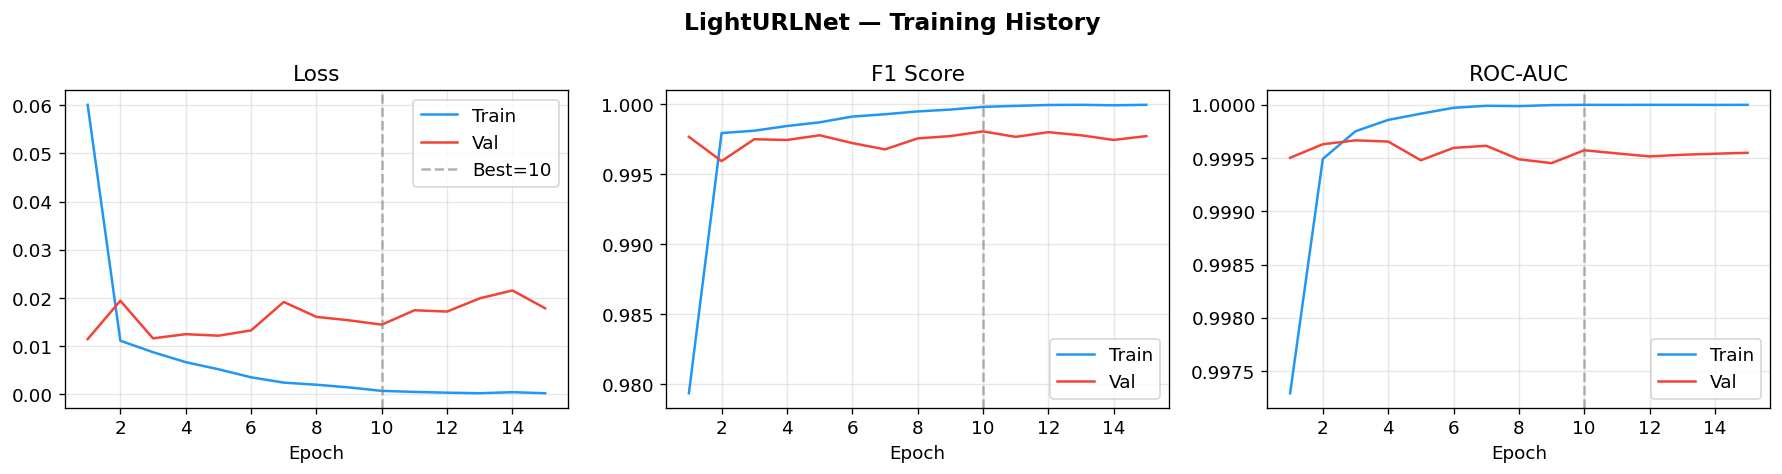

✓ Saved → lighturlnet_artifacts/plots/training_curves.png


In [21]:
# ── Training curves ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_x, history["train_loss"], label="Train", color="#2196F3")
axes[0].plot(epochs_x, history["val_loss"],   label="Val",   color="#F44336")
axes[0].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"Best={best_epoch}")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

# F1
axes[1].plot(epochs_x, history["train_f1"], label="Train", color="#2196F3")
axes[1].plot(epochs_x, history["val_f1"],   label="Val",   color="#F44336")
axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6)
axes[1].set_title("F1 Score"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(epochs_x, history["train_auc"], label="Train", color="#2196F3")
axes[2].plot(epochs_x, history["val_auc"],   label="Val",   color="#F44336")
axes[2].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6)
axes[2].set_title("ROC-AUC"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("LightURLNet — Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
curve_path = PLOT_DIR / "training_curves.png"
plt.savefig(curve_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"✓ Saved → {curve_path}")

## Section 9: Class Imbalance — Verification

In [22]:
# ── Load best checkpoint for evaluation ──────────────────────────────────────

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Loaded best checkpoint (epoch={ckpt['epoch']}, val_F1={ckpt['val_f1']:.4f})")
print(f"Strategy: {'WeightedRandomSampler' if USE_SAMPLER else 'pos_weight in BCEWithLogitsLoss'}")

Loaded best checkpoint (epoch=10, val_F1=0.9981)
Strategy: pos_weight in BCEWithLogitsLoss


## Section 10: Evaluation

In [23]:
# ── Full evaluation on test set ───────────────────────────────────────────────

def collect_predictions(
    model  : nn.Module,
    loader : DataLoader,
) -> tuple[list[int], list[float]]:
    """Collect ground-truth labels and predicted probabilities."""
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb)
            probs = torch.sigmoid(out).cpu().tolist()
            all_probs .extend(probs)
            all_labels.extend(yb.tolist())
    return all_labels, all_probs


test_labels, test_probs = collect_predictions(model, test_loader)
test_preds = [1 if p >= 0.5 else 0 for p in test_probs]

test_metrics = {
    "accuracy" : accuracy_score(test_labels, test_preds),
    "precision": precision_score(test_labels, test_preds, zero_division=0),
    "recall"   : recall_score(test_labels, test_preds, zero_division=0),
    "f1"       : f1_score(test_labels, test_preds, zero_division=0),
    "roc_auc"  : roc_auc_score(test_labels, test_probs),
    "pr_auc"   : average_precision_score(test_labels, test_probs),
}

print("\n" + "="*50)
print("  TEST SET EVALUATION")
print("="*50)
for k, v in test_metrics.items():
    print(f"  {k:<12}: {v:.4f}")
print("="*50)


  TEST SET EVALUATION
  accuracy    : 0.9981
  precision   : 0.9997
  recall      : 0.9964
  f1          : 0.9981
  roc_auc     : 0.9996
  pr_auc      : 0.9997


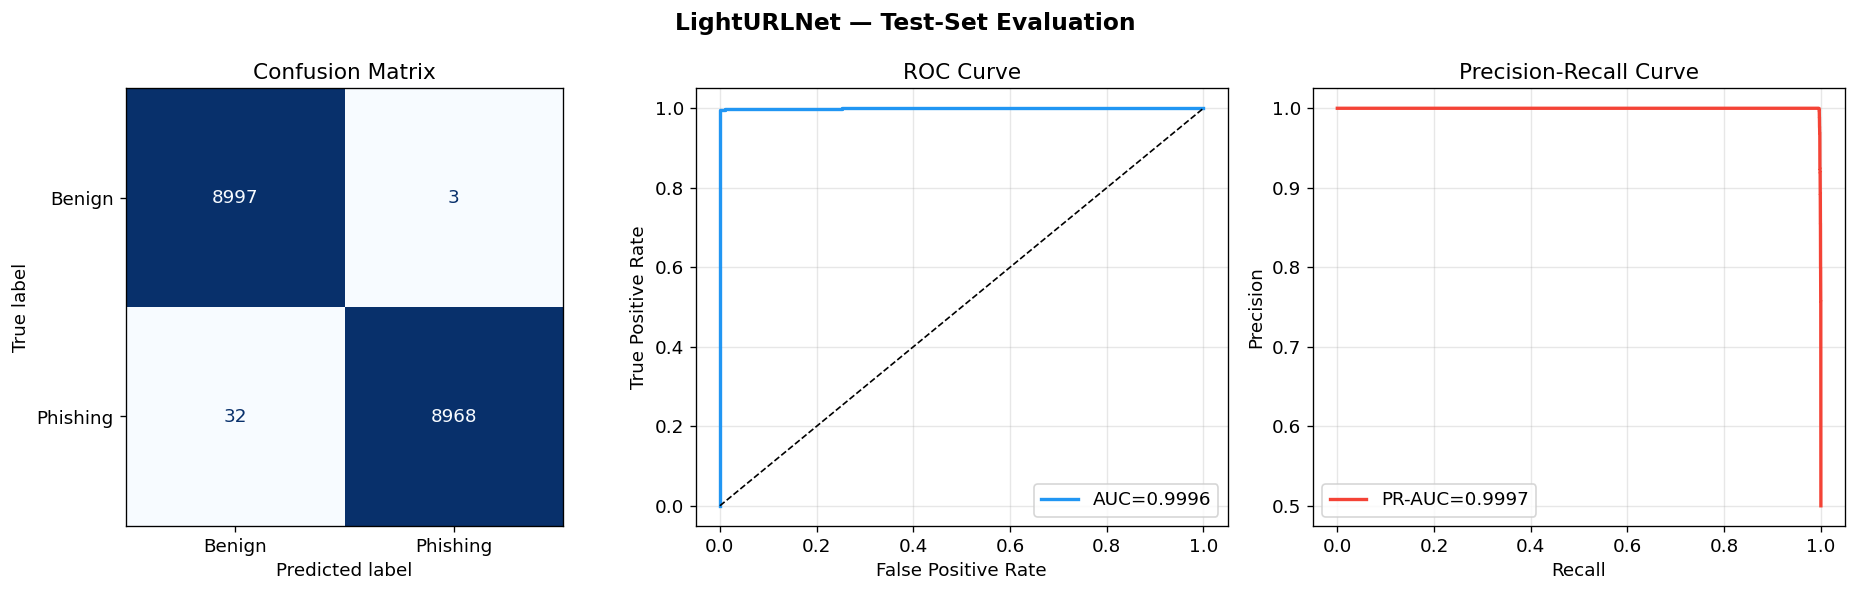

✓ Saved → lighturlnet_artifacts/plots/evaluation_plots.png


In [24]:
# ── Plots: Confusion matrix, ROC, PR curves ───────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("LightURLNet — Test-Set Evaluation", fontsize=14, fontweight="bold")

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Phishing"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color="#2196F3", lw=2, label=f"AUC={test_metrics['roc_auc']:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# PR Curve
prec_curve, rec_curve, _ = precision_recall_curve(test_labels, test_probs)
axes[2].plot(rec_curve, prec_curve, color="#F44336", lw=2, label=f"PR-AUC={test_metrics['pr_auc']:.4f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend(loc="lower left")
axes[2].grid(alpha=0.3)

plt.tight_layout()
eval_path = PLOT_DIR / "evaluation_plots.png"
plt.savefig(eval_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"✓ Saved → {eval_path}")

## Section 11: Threshold Optimization

Threshold optimisation results (selected rows):
 threshold  precision  recall     f1
    0.0500     0.9966  0.9967 0.9966
    0.1000     0.9983  0.9964 0.9974
    0.1500     0.9987  0.9964 0.9976
    0.2000     0.9992  0.9964 0.9978
    0.2500     0.9992  0.9964 0.9978
    0.3000     0.9994  0.9964 0.9979
    0.3500     0.9994  0.9964 0.9979
    0.4000     0.9994  0.9964 0.9979
    0.4500     0.9997  0.9964 0.9981
    0.5000     0.9997  0.9964 0.9981
    0.5500     0.9997  0.9963 0.9980
    0.6000     0.9998  0.9961 0.9979
    0.6500     0.9998  0.9961 0.9979
    0.7000     0.9998  0.9961 0.9979
    0.7500     0.9998  0.9961 0.9979
    0.8000     0.9998  0.9960 0.9979
    0.8500     0.9998  0.9959 0.9978
    0.9000     0.9998  0.9958 0.9978
    0.9500     0.9998  0.9957 0.9977

Best F1        threshold: 0.45  (F1=0.9981)
Best Recall    threshold: 0.05  (Rec=0.9967)
Best Precision threshold: 0.60  (Pre=0.9998)


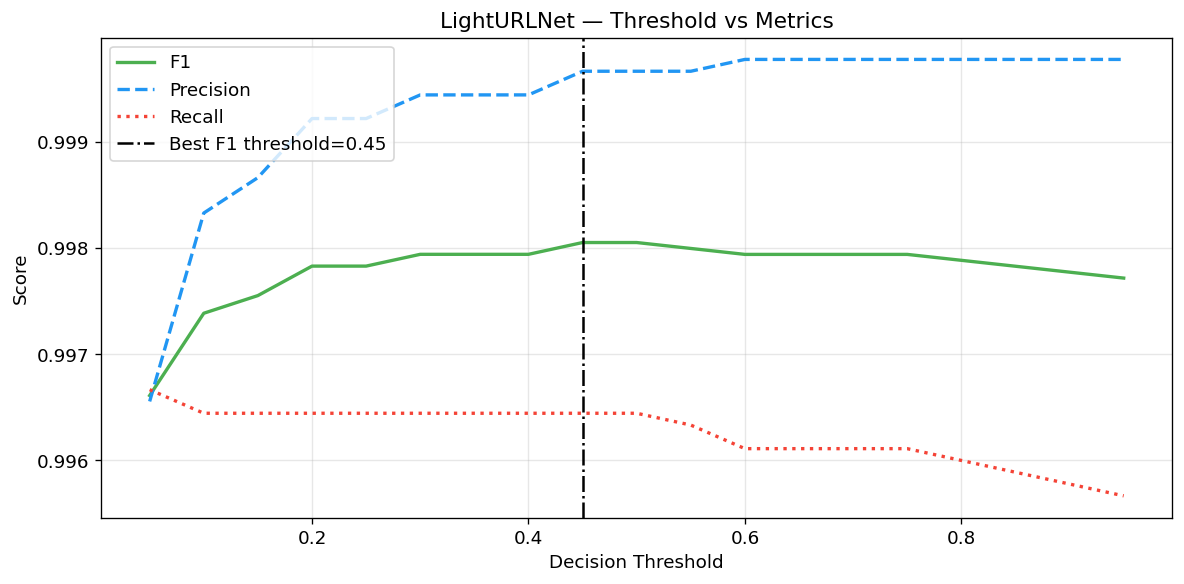

✓ Saved → lighturlnet_artifacts/plots/threshold_optimization.png


In [25]:
# ── Sweep thresholds 0.05 → 0.95 ─────────────────────────────────────────────

thresholds = [round(t, 2) for t in list(map(lambda x: x/100, range(5, 96, 5)))]

threshold_records = []
for thr in thresholds:
    preds_t = [1 if p >= thr else 0 for p in test_probs]
    prec_t  = precision_score(test_labels, preds_t, zero_division=0)
    rec_t   = recall_score(test_labels, preds_t, zero_division=0)
    f1_t    = f1_score(test_labels, preds_t, zero_division=0)
    threshold_records.append({
        "threshold": thr,
        "precision": prec_t,
        "recall"   : rec_t,
        "f1"       : f1_t,
    })

thr_df = pd.DataFrame(threshold_records)

best_f1_row        = thr_df.loc[thr_df["f1"].idxmax()]
best_recall_row    = thr_df.loc[thr_df["recall"].idxmax()]
best_precision_row = thr_df.loc[thr_df["precision"].idxmax()]

print("Threshold optimisation results (selected rows):")
print(thr_df.to_string(index=False, float_format="{:.4f}".format))
print()
print(f"Best F1        threshold: {best_f1_row['threshold']:.2f}  (F1={best_f1_row['f1']:.4f})")
print(f"Best Recall    threshold: {best_recall_row['threshold']:.2f}  (Rec={best_recall_row['recall']:.4f})")
print(f"Best Precision threshold: {best_precision_row['threshold']:.2f}  (Pre={best_precision_row['precision']:.4f})")

OPTIMAL_THRESHOLD: float = float(best_f1_row["threshold"])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_df["threshold"], thr_df["f1"],        label="F1",        color="#4CAF50", lw=2)
ax.plot(thr_df["threshold"], thr_df["precision"], label="Precision", color="#2196F3", lw=2, linestyle="--")
ax.plot(thr_df["threshold"], thr_df["recall"],    label="Recall",    color="#F44336", lw=2, linestyle=":")
ax.axvline(OPTIMAL_THRESHOLD, color="black", linestyle="-.", linewidth=1.5,
           label=f"Best F1 threshold={OPTIMAL_THRESHOLD:.2f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("LightURLNet — Threshold vs Metrics")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
thr_path = PLOT_DIR / "threshold_optimization.png"
plt.savefig(thr_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"✓ Saved → {thr_path}")

## Section 12: Error Analysis

In [26]:
# ── Collect FPs and FNs ───────────────────────────────────────────────────────

error_df = pd.DataFrame({
    "url"  : X_test,
    "label": test_labels,
    "prob" : test_probs,
})
error_df["pred"] = (error_df["prob"] >= OPTIMAL_THRESHOLD).astype(int)

false_positives = error_df[(error_df["label"] == 0) & (error_df["pred"] == 1)].copy()
false_negatives = error_df[(error_df["label"] == 1) & (error_df["pred"] == 0)].copy()

false_positives = false_positives.sort_values("prob", ascending=False)
false_negatives = false_negatives.sort_values("prob", ascending=True)

print(f"False Positives (benign → predicted phishing) : {len(false_positives):,}")
print(f"False Negatives (phishing → predicted benign)  : {len(false_negatives):,}")

print("\n── Top-15 False Positives (most confident wrong predictions) ──")
print(false_positives[["url", "prob"]].head(15).to_string(index=False))

print("\n── Top-15 False Negatives (missed phishing URLs) ──")
print(false_negatives[["url", "prob"]].head(15).to_string(index=False))

False Positives (benign → predicted phishing) : 3
False Negatives (phishing → predicted benign)  : 32

── Top-15 False Positives (most confident wrong predictions) ──
                              url     prob
          https://hyperliquid.xyz 0.980251
https://www.mymobilityscooters.uk 0.976072
             https://jizhi106.top 0.583955

── Top-15 False Negatives (missed phishing URLs) ──
                            url         prob
   https://yourhealthyfirst.com 2.818797e-07
         https://buypanthom.com 5.275658e-06
             https://ljlpnl.com 6.725584e-06
             https://uvebto.com 1.279300e-05
         https://santhotels.com 1.295137e-05
              https://iknsvx.cn 1.365747e-05
              https://axrpez.cn 2.914364e-05
      https://rise-of-indie.com 3.158900e-05
            https://nk-link.com 3.905293e-05
             https://seoiya.com 5.610102e-05
        https://citronnoire.com 6.677731e-05
           https://shanxicu.com 8.611949e-05
    https://mypurplecon

In [27]:
# ── URL-level pattern analysis ────────────────────────────────────────────────

def url_pattern_summary(urls: list[str]) -> dict:
    """Compute shallow structural stats for a list of URLs."""
    lengths   = [len(u) for u in urls]
    dots      = [u.count(".") for u in urls]
    hyphens   = [u.count("-") for u in urls]
    has_https = [u.startswith("https") for u in urls]
    return {
        "count"         : len(urls),
        "avg_len"       : float(np.mean(lengths)) if lengths else 0,
        "avg_dots"      : float(np.mean(dots))    if dots    else 0,
        "avg_hyphens"   : float(np.mean(hyphens)) if hyphens else 0,
        "https_ratio"   : float(np.mean(has_https)) if has_https else 0,
    }

fp_stats = url_pattern_summary(false_positives["url"].tolist())
fn_stats = url_pattern_summary(false_negatives["url"].tolist())
all_stats = url_pattern_summary(X_test)

analysis_df = pd.DataFrame(
    [all_stats, fp_stats, fn_stats],
    index=["All test URLs", "False Positives", "False Negatives"]
)
print("\n── Error Pattern Analysis ──")
print(analysis_df.to_string(float_format="{:.2f}".format))

print("\n── Engineer Insights ──")
print(f"• FP avg length ({fp_stats['avg_len']:.0f}) vs overall ({all_stats['avg_len']:.0f}): "
      + ("FPs are longer" if fp_stats['avg_len'] > all_stats['avg_len'] else "FPs are shorter"))
print(f"• FN avg hyphens ({fn_stats['avg_hyphens']:.2f}) vs overall ({all_stats['avg_hyphens']:.2f}): "
      + ("FNs use fewer hyphens (stealthy)" if fn_stats['avg_hyphens'] < all_stats['avg_hyphens']
         else "FNs use more hyphens"))
print(f"• FN HTTPS ratio = {fn_stats['https_ratio']:.2f}: "
      + ("many missed phishing use HTTPS (trust signal exploited)" if fn_stats['https_ratio'] > 0.5
         else "most missed phishing use HTTP"))


── Error Pattern Analysis ──
                 count  avg_len  avg_dots  avg_hyphens  https_ratio
All test URLs    18000    38.18      1.47         0.70         0.90
False Positives      3    25.33      1.33         0.00         1.00
False Negatives     32    22.75      1.09         0.16         1.00

── Engineer Insights ──
• FP avg length (25) vs overall (38): FPs are shorter
• FN avg hyphens (0.16) vs overall (0.70): FNs use fewer hyphens (stealthy)
• FN HTTPS ratio = 1.00: many missed phishing use HTTPS (trust signal exploited)


## Section 13: Interpretability — Character-Level Attribution


URL    : https://secure-paypal-login-verification.com/account/restore
Label  : Phishing   |   Predicted prob: 1.0000


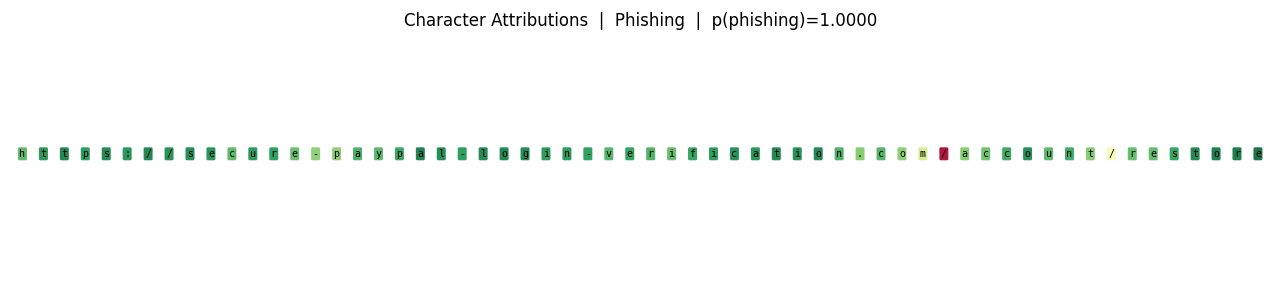

✓ Saved → lighturlnet_artifacts/plots/attribution_phishing.png

URL    : https://google.com/search?q=python+tutorial
Label  : Benign   |   Predicted prob: 1.0000


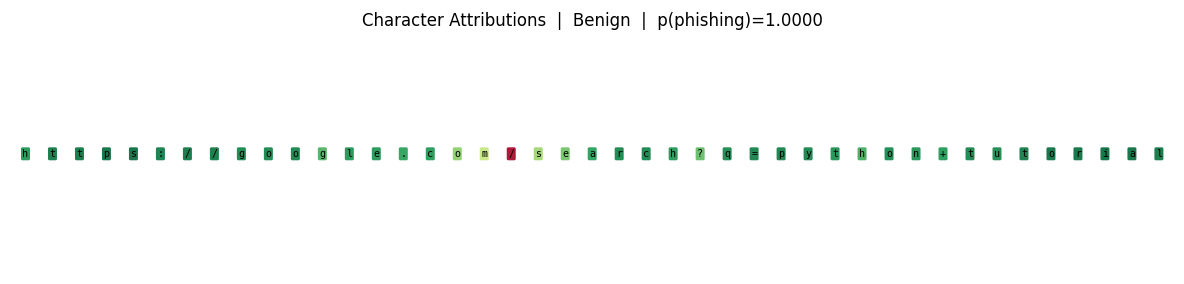

✓ Saved → lighturlnet_artifacts/plots/attribution_benign.png


In [28]:
# ── Integrated Gradients implementation ──────────────────────────────────────

class IntegratedGradients:
    """
    Character-level Integrated Gradients for LightURLNet.
    Approximates: IG_i = (x_i - x'_i) * integral_0^1 d(F) / d(embedding) dt
    """

    def __init__(self, model: nn.Module, steps: int = 50) -> None:
        self.model = model
        self.steps = steps

    def attribute(self, url_tensor: torch.Tensor) -> np.ndarray:
        """
        Parameters
        ----------
        url_tensor : LongTensor of shape (L,) — single URL

        Returns
        -------
        attribution : ndarray of shape (L,) — per-character importance scores
        """
        self.model.eval()
        x = url_tensor.unsqueeze(0).to(DEVICE)         # (1, L)

        # Baseline = all-PAD sequence
        baseline = torch.zeros_like(x)

        # Embed baseline and input
        with torch.no_grad():
            emb_base  = self.model.embedding(baseline).detach()  # (1, L, E)
            emb_input = self.model.embedding(x).detach()         # (1, L, E)

        # Interpolate embeddings
        alphas     = torch.linspace(0, 1, self.steps).to(DEVICE)
        grad_accum = torch.zeros_like(emb_input)                 # (1, L, E)

        for alpha in alphas:
            interp_emb = emb_base + alpha * (emb_input - emb_base)
            interp_emb = interp_emb.requires_grad_(True)

            # Forward through the post-embedding layers
            e = interp_emb.transpose(1, 2)    # (1, E, L)
            b3 = self.model.branch3(e)
            b5 = self.model.branch5(e)
            b7 = self.model.branch7(e)
            fused = torch.cat([b3, b5, b7], dim=1)
            fused = self.model.fusion_conv(fused)
            fused = self.model.channel_attn(fused)
            pooled = self.model.pool(fused).squeeze(-1)
            out = self.model.classifier(pooled).squeeze()

            grad = torch.autograd.grad(out, interp_emb)[0]   # (1, L, E)
            grad_accum += grad.detach()

        ig = (emb_input - emb_base) * (grad_accum / self.steps)  # (1, L, E)
        attribution = ig.squeeze(0).norm(dim=-1).cpu().numpy()    # (L,)
        return attribution


def explain_url(url: str, label: str = "?") -> None:
    """Print and plot character-level attributions for a single URL."""
    tokens = tokenizer(url)
    ig_engine = IntegratedGradients(model, steps=50)

    with torch.no_grad():
        prob = torch.sigmoid(model(tokens.unsqueeze(0).to(DEVICE))).item()

    attribution = ig_engine.attribute(tokens)

    # Trim to actual URL length
    url_len  = min(len(url), MAX_LEN)
    chars    = list(url[:url_len])
    scores   = attribution[:url_len]

    # Normalise
    scores   = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    print(f"\nURL    : {url}")
    print(f"Label  : {label}   |   Predicted prob: {prob:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(max(10, url_len * 0.18), 2.5))
    cmap    = plt.cm.RdYlGn_r
    for i, (ch, sc) in enumerate(zip(chars, scores)):
        color = cmap(sc)
        ax.text(i, 0.5, ch,
                ha="center", va="center",
                fontsize=max(6, min(10, 200 // url_len)),
                fontfamily="monospace",
                color="black",
                bbox=dict(facecolor=color, alpha=0.9, boxstyle="round,pad=0.15",
                          edgecolor="none"))
    ax.set_xlim(-0.5, url_len - 0.5)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(f"Character Attributions  |  {label}  |  p(phishing)={prob:.4f}",
                 fontsize=10)
    plt.tight_layout()
    save_name = PLOT_DIR / f"attribution_{label.lower()}.png"
    plt.savefig(save_name, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"✓ Saved → {save_name}")


# ── Explain one phishing + one benign URL ────────────────────────────────────
explain_url("https://secure-paypal-login-verification.com/account/restore", label="Phishing")
explain_url("https://google.com/search?q=python+tutorial",                  label="Benign")

## Section 14: Benchmarking

In [29]:
# ── Inference latency benchmarking ────────────────────────────────────────────

import statistics

def benchmark_latency(
    model     : nn.Module,
    device    : torch.device,
    n_warmup  : int = 20,
    n_runs    : int = 200,
    batch_size: int = 1,
) -> dict:
    """
    Measure per-sample latency on *device* using batch_size=1 (single URL).
    Returns mean, median, p95, p99 in milliseconds.
    """
    model.eval()
    dummy = torch.zeros(batch_size, MAX_LEN, dtype=torch.long).to(device)

    # Warm-up
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(dummy)
    if device.type == "cuda":
        torch.cuda.synchronize()

    latencies = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _  = model(dummy)
            if device.type == "cuda":
                torch.cuda.synchronize()
            latencies.append((time.perf_counter() - t0) * 1000)  # ms

    return {
        "device"   : str(device),
        "batch_size": batch_size,
        "mean_ms"  : statistics.mean(latencies),
        "median_ms": statistics.median(latencies),
        "p95_ms"   : sorted(latencies)[int(0.95 * n_runs)],
        "p99_ms"   : sorted(latencies)[int(0.99 * n_runs)],
        "throughput_per_s": 1000.0 / statistics.mean(latencies) * batch_size,
    }


# CPU benchmark (single URL)
model_cpu = model.to(torch.device("cpu"))
bench_cpu_1 = benchmark_latency(model_cpu, torch.device("cpu"), batch_size=1)

# CPU batch benchmark
bench_cpu_b = benchmark_latency(model_cpu, torch.device("cpu"),
                                 batch_size=64, n_runs=100)

# GPU benchmark if available
bench_gpu = None
if DEVICE.type == "cuda":
    model_gpu = model.to(DEVICE)
    bench_gpu = benchmark_latency(model_gpu, DEVICE, batch_size=1)
    bench_gpu_b = benchmark_latency(model_gpu, DEVICE, batch_size=512, n_runs=100)
    model.to(DEVICE)  # restore
else:
    model.to(DEVICE)

print("\n" + "="*60)
print("  BENCHMARK REPORT")
print("="*60)
for b in [bench_cpu_1, bench_cpu_b]:
    print(f"  Device={b['device']:<6} | Batch={b['batch_size']:>4} | "
          f"Mean={b['mean_ms']:>7.3f}ms | P95={b['p95_ms']:>7.3f}ms | "
          f"Throughput={b['throughput_per_s']:>8,.0f} URL/s")
if bench_gpu:
    print(f"  Device={bench_gpu['device']:<6} | Batch={bench_gpu['batch_size']:>4} | "
          f"Mean={bench_gpu['mean_ms']:>7.3f}ms | P95={bench_gpu['p95_ms']:>7.3f}ms | "
          f"Throughput={bench_gpu['throughput_per_s']:>8,.0f} URL/s")
    print(f"  Device={bench_gpu_b['device']:<6} | Batch={bench_gpu_b['batch_size']:>4} | "
          f"Mean={bench_gpu_b['mean_ms']:>7.3f}ms | P95={bench_gpu_b['p95_ms']:>7.3f}ms | "
          f"Throughput={bench_gpu_b['throughput_per_s']:>8,.0f} URL/s")
print("="*60)
target_ok = bench_cpu_1["mean_ms"] < 1.0
print(f"  Target <1ms CPU single URL: {'✓ PASS' if target_ok else '✗ MISS'} "
      f"({bench_cpu_1['mean_ms']:.3f}ms)")


  BENCHMARK REPORT
  Device=cpu    | Batch=   1 | Mean=  3.212ms | P95=  3.534ms | Throughput=     311 URL/s
  Device=cpu    | Batch=  64 | Mean= 99.309ms | P95=116.196ms | Throughput=     644 URL/s
  Device=cuda   | Batch=   1 | Mean=  1.746ms | P95=  1.920ms | Throughput=     573 URL/s
  Device=cuda   | Batch= 512 | Mean= 35.671ms | P95= 36.188ms | Throughput=  14,353 URL/s
  Target <1ms CPU single URL: ✗ MISS (3.212ms)


## Section 15: Model Export

In [30]:


config = {
    "vocab_size": vocab.vocab_size,
    "embed_dim": EMBED_DIM,
    "num_filters": CNN_FILTERS,
    "dropout": DROPOUT,
    "max_len": MAX_LEN,
}

CONFIG_PATH = ARTIFACT_DIR / "config.json"

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=4)

print(f"✓ Config saved → {CONFIG_PATH}")

✓ Config saved → lighturlnet_artifacts/config.json


In [31]:
# ── Export: Raw PyTorch state dict (.pt) ─────────────────────────────────────

torch.save({
    "model_state" : model.state_dict(),
    "config"      : {
        "vocab_size" : vocab.vocab_size,
        "embed_dim"  : EMBED_DIM,
        "num_filters": CNN_FILTERS,
        "dropout"    : DROPOUT,
        "max_len"    : MAX_LEN,
    },a
    "test_metrics": test_metrics,
}, PT_PATH)
print(f"✓ PyTorch state dict saved → {PT_PATH}")

SyntaxError: ':' expected after dictionary key (4090759057.py, line 11)

In [ ]:
# ── Export: TorchScript (.ts) ─────────────────────────────────────────────────

model_cpu = model.to(torch.device("cpu"))
model_cpu.eval()

try:
    example_input = torch.zeros(1, MAX_LEN, dtype=torch.long)
    scripted = torch.jit.trace(model_cpu, example_input)
    scripted.save(str(TS_PATH))
    print(f"✓ TorchScript saved → {TS_PATH}")

    # Validate
    loaded_ts = torch.jit.load(str(TS_PATH))
    loaded_ts.eval()
    with torch.no_grad():
        out_ts = torch.sigmoid(loaded_ts(example_input))
    print(f"  TorchScript inference test: p={out_ts.item():.4f}  ✓")
except Exception as exc:
    print(f"[WARN] TorchScript export failed: {exc}")

model.to(DEVICE)

In [ ]:
# ─────────────────────────────────────────────────────────────
# Export LightURLNet → ONNX
# ─────────────────────────────────────────────────────────────

import copy
import numpy as np
import torch
import onnx
import onnxruntime as ort

print("Preparing model for ONNX export...")

# Create a completely independent CPU copy
model_cpu = copy.deepcopy(model).cpu()
model_cpu.eval()

# Verify all parameters are on CPU
devices = {p.device.type for p in model_cpu.parameters()}
print("Model devices:", devices)

if devices != {"cpu"}:
    raise RuntimeError(f"Model still contains non-CPU tensors: {devices}")

# Dummy input
dummy_input = torch.zeros(
    (1, MAX_LEN),
    dtype=torch.long,
    device="cpu"
)

try:
    # Export
    torch.onnx.export(
        model_cpu,
        dummy_input,
        str(ONNX_PATH),
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names=["url_chars"],
        output_names=["logit"],
        dynamic_axes={
            "url_chars": {0: "batch_size"},
            "logit": {0: "batch_size"}
        },
        dynamo=False,   # More stable than new exporter
        verbose=False
    )

    print(f"✓ ONNX exported → {ONNX_PATH}")

    # ---------------------------------------------------------
    # ONNX Validation
    # ---------------------------------------------------------

    onnx_model = onnx.load(str(ONNX_PATH))
    onnx.checker.check_model(onnx_model)

    print("✓ ONNX graph check PASS")

    # ---------------------------------------------------------
    # ONNX Runtime Validation
    # ---------------------------------------------------------

    ort_session = ort.InferenceSession(
        str(ONNX_PATH),
        providers=["CPUExecutionProvider"]
    )

    ort_inputs = {
        "url_chars": dummy_input.numpy()
    }

    ort_output = ort_session.run(None, ort_inputs)

    ort_logit = float(ort_output[0][0])
    ort_prob = 1.0 / (1.0 + np.exp(-ort_logit))

    with torch.no_grad():
        pt_logit = model_cpu(dummy_input)
        pt_prob = torch.sigmoid(pt_logit).item()

    diff = abs(pt_prob - ort_prob)

    print(f"PyTorch prob : {pt_prob:.8f}")
    print(f"ONNX prob    : {ort_prob:.8f}")
    print(f"Abs diff     : {diff:.8e}")

    if diff < 1e-4:
        print("✓ ONNX matches PyTorch")
    else:
        print("⚠ Output difference larger than expected")

except Exception as exc:
    print("\n[ONNX EXPORT FAILED]")
    print(type(exc).__name__)
    print(exc)

# Move original model back to training/inference device
model.to(DEVICE)

In [ ]:
# ── Export: ONNX (.onnx) ──────────────────────────────────────────────────────

model_cpu.eval()
dummy_input = torch.zeros(1, MAX_LEN, dtype=torch.long)

try:
    torch.onnx.export(
        model_cpu,
        dummy_input,
        str(ONNX_PATH),
        opset_version=14,
        input_names=["url_chars"],
        output_names=["logit"],
        dynamic_axes={
            "url_chars": {0: "batch_size"},
            "logit"    : {0: "batch_size"},
        },
        verbose=False,
    )
    print(f"✓ ONNX exported → {ONNX_PATH}")

    # Validate with ONNX checker
    onnx_model = onnx.load(str(ONNX_PATH))
    onnx.checker.check_model(onnx_model)
    print("  ONNX graph check: ✓ PASS")

    # Validate with OnnxRuntime
    ort_sess = ort.InferenceSession(str(ONNX_PATH))
    ort_input  = {"url_chars": dummy_input.numpy()}
    ort_output = ort_sess.run(None, ort_input)
    ort_prob   = 1.0 / (1.0 + float(np.exp(-ort_output[0][0])))

    with torch.no_grad():
        pt_prob = torch.sigmoid(model_cpu(dummy_input)).item()

    diff = abs(ort_prob - pt_prob)
    print(f"  PyTorch prob : {pt_prob:.6f}")
    print(f"  ONNX prob    : {ort_prob:.6f}")
    print(f"  Abs diff     : {diff:.2e}  {'✓' if diff < 1e-4 else '✗'}")

except Exception as exc:
    print(f"[WARN] ONNX export failed: {exc}")

model.to(DEVICE)

## Section 16: Production Inference API

In [ ]:
# ── predict_url() production function ────────────────────────────────────────

def predict_url(url: str) -> dict:
    """
    Classify a single URL as benign or phishing.

    Parameters
    ----------
    url : str
        Raw URL string (may be malformed or empty).

    Returns
    -------
    dict
        {
            "url"        : str,
            "prediction" : "phishing" | "benign",
            "probability": float,      # p(phishing)
            "confidence" : float,      # = max(p, 1-p)
        }
    """
    # ── Guard: empty / non-string ─────────────────────────────────────────────
    if not isinstance(url, str) or not url.strip():
        return {
            "url"        : str(url),
            "prediction" : "benign",
            "probability": 0.0,
            "confidence" : 1.0,
            "error"      : "empty or invalid input",
        }

    # ── Encode ────────────────────────────────────────────────────────────────
    try:
        token = tokenizer(url).unsqueeze(0).to(DEVICE)   # (1, MAX_LEN)
    except Exception as exc:
        return {
            "url"        : url,
            "prediction" : "benign",
            "probability": 0.0,
            "confidence" : 1.0,
            "error"      : f"encoding error: {exc}",
        }

    # ── Inference ─────────────────────────────────────────────────────────────
    model.eval()
    try:
        with torch.no_grad():
            logit = model(token)
            prob  = float(torch.sigmoid(logit).item())
    except Exception as exc:
        return {
            "url"        : url,
            "prediction" : "error",
            "probability": -1.0,
            "confidence" : 0.0,
            "error"      : f"inference error: {exc}",
        }

    # ── Threshold & format ────────────────────────────────────────────────────
    is_phishing = prob >= OPTIMAL_THRESHOLD
    return {
        "url"        : url,
        "prediction" : "phishing" if is_phishing else "benign",
        "probability": round(prob, 6),
        "confidence" : round(max(prob, 1 - prob), 6),
    }


# ── Batch predict helper ──────────────────────────────────────────────────────
def predict_urls(urls: list[str]) -> list[dict]:
    """Predict a list of URLs (vectorised)."""
    return [predict_url(u) for u in urls]

In [ ]:
# ── Smoke-test production API ─────────────────────────────────────────────────

test_cases = [
    "https://secure-paypal-login-verify.tk/account/suspend",
    "https://amazon.com/gp/product/B08L5TNJHG",
    "http://signin-apple-id.gq/itunes/verify-payment",
    "https://github.com/anthropics/anthropic-sdk-python",
    "",
    "notaurl",
    "x" * 500,
    "https://microsoft-security-alert-update.xyz/login",
    "https://bbc.co.uk/news/technology",
    "http://192.168.1.1/admin",
]

print(f"{'URL':<55} {'Pred':<10} {'P(phishing)':>12} {'Confidence':>12}")
print("-" * 93)
for url in test_cases:
    result = predict_url(url)
    disp   = (url[:52] + "...") if len(url) > 55 else url
    print(f"{disp:<55} {result['prediction']:<10} "
          f"{result['probability']:>12.4f} {result['confidence']:>12.4f}")

## Section 17: Deployment Report

In [ ]:
# ── Auto-generate deployment report ──────────────────────────────────────────

def generate_report() -> str:
    """Compile all metrics and artefact info into a markdown report."""
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    pt_size_mb  = PT_PATH.stat().st_size  / 1e6 if PT_PATH.exists()   else 0
    ts_size_mb  = TS_PATH.stat().st_size  / 1e6 if TS_PATH.exists()   else 0
    onnx_size_mb= ONNX_PATH.stat().st_size/ 1e6 if ONNX_PATH.exists() else 0

    lines = [
        "# LightURLNet — AShieldER Deployment Report",
        f"Generated: {ts}",
        "",
        "---",
        "",
        "## 1. Model Architecture",
        f"- **Name**          : LightURLNet",
        f"- **Type**          : Character-level Multi-Scale CNN",
        f"- **Total params**  : {total_params:,}",
        f"- **Trainable**     : {trainable_params:,}",
        f"- **Size (FP32)**   : {model_size_mb:.2f} MB",
        f"- **Vocab size**    : {vocab.vocab_size}",
        f"- **Max URL len**   : {MAX_LEN}",
        f"- **Embed dim**     : {EMBED_DIM}",
        f"- **CNN filters**   : {CNN_FILTERS}",
        f"- **Kernels**       : 3, 5, 7",
        f"- **Dropout**       : {DROPOUT}",
        "",
        "## 2. Dataset Statistics",
        f"- **Total samples** : {n_total:,}",
        f"- **Benign**        : {n_benign:,}",
        f"- **Phishing**      : {n_phishing:,}",
        f"- **Duplicates removed**: {n_dupes:,}",
        f"- **Avg URL length**: {avg_len:.1f}",
        f"- **Max URL length**: {max_len}",
        f"- **Vocab chars**   : {len(vocab_chars)}",
        "",
        "## 3. Training Configuration",
        f"- **Epochs trained**: {best_epoch}",
        f"- **Batch size**    : {BATCH_SIZE}",
        f"- **Learning rate** : {LR}",
        f"- **Weight decay**  : {WEIGHT_DECAY}",
        f"- **Optimiser**     : AdamW + CosineAnnealingLR",
        f"- **Imbalance**     : {'WeightedRandomSampler' if USE_SAMPLER else 'pos_weight loss'}",
        "",
        "## 4. Test Metrics (threshold=0.50)",
    ]
    for k, v in test_metrics.items():
        lines.append(f"- **{k}** : {v:.4f}")
    lines += [
        "",
        f"## 5. Optimal Threshold",
        f"- **Best F1 threshold** : {OPTIMAL_THRESHOLD:.2f}",
        f"- **F1 @ optimal**      : {best_f1_row['f1']:.4f}",
        f"- **Recall @ optimal**  : {best_f1_row['recall']:.4f}",
        f"- **Precision @ optimal**: {best_f1_row['precision']:.4f}",
        "",
        "## 6. Inference Benchmarks",
        f"- **CPU single URL (mean)** : {bench_cpu_1['mean_ms']:.3f} ms",
        f"- **CPU single URL (p95)**  : {bench_cpu_1['p95_ms']:.3f} ms",
        f"- **CPU throughput**        : {bench_cpu_1['throughput_per_s']:,.0f} URL/s",
        f"- **CPU batch={bench_cpu_b['batch_size']} throughput** : {bench_cpu_b['throughput_per_s']:,.0f} URL/s",
    ]
    if bench_gpu:
        lines += [
            f"- **GPU single URL (mean)** : {bench_gpu['mean_ms']:.3f} ms",
            f"- **GPU throughput**        : {bench_gpu['throughput_per_s']:,.0f} URL/s",
        ]
    lines += [
        f"- **Target <1ms CPU**       : {'✓ PASS' if bench_cpu_1['mean_ms'] < 1.0 else '✗ MISS'}",
        "",
        "## 7. Exported Artefacts",
        f"| File | Size |",
        f"|------|------|",
        f"| `lighturlnet.pt`   | {pt_size_mb:.2f} MB |",
        f"| `lighturlnet.ts`   | {ts_size_mb:.2f} MB |",
        f"| `lighturlnet.onnx` | {onnx_size_mb:.2f} MB |",
        f"| `lighturlnet_dataset.csv` | dataset |",
        f"| `vocab.json`       | vocabulary |",
        "",
        "## 8. Deployment Notes",
        "- Pure character-level model — no hand-crafted features required.",
        "- Input: raw URL string → character indices → prediction.",
        "- ONNX export supports browser (ONNX.js / onnxruntime-web) and edge (ONNX Runtime) deployment.",
        "- TorchScript export supports C++ / mobile (LibTorch) deployment.",
        f"- Optimal decision threshold: **{OPTIMAL_THRESHOLD:.2f}** (tune per deployment context).",
        "- For Chrome Extension: use `lighturlnet.onnx` via `onnxruntime-web`.",
        "- For production API: wrap `predict_url()` behind a FastAPI/Flask endpoint.",
        "",
        "---",
        "_Report auto-generated by LightURLNet training notebook._",
    ]
    return "\n".join(lines)


report_text = generate_report()
REPORT_PATH.write_text(report_text, encoding="utf-8")
print(report_text)
print(f"\n✓ Report saved → {REPORT_PATH}")

In [ ]:
# ── Final artefact inventory ──────────────────────────────────────────────────

import shutil

print("\n" + "="*60)
print("  FINAL ARTIFACT INVENTORY")
print("="*60)
artifacts = [
    DATASET_PATH,
    VOCAB_PATH,
    CKPT_PATH,
    PT_PATH,
    TS_PATH,
    ONNX_PATH,
    REPORT_PATH,
    PLOT_DIR / "eda_overview.png",
    PLOT_DIR / "training_curves.png",
    PLOT_DIR / "evaluation_plots.png",
    PLOT_DIR / "threshold_optimization.png",
    PLOT_DIR / "attribution_phishing.png",
    PLOT_DIR / "attribution_benign.png",
]
for path in artifacts:
    path = Path(path)
    exists = path.exists()
    size   = path.stat().st_size / 1e3 if exists else 0
    status = f"✓  {size:>8.1f} KB" if exists else "✗  MISSING"
    print(f"  {status}   {path}")

print("="*60)
print("\n✓ LightURLNet training complete. All artifacts saved.")